# Лабораторная работа №1
## VAE vs GAN: сравнительный анализ генеративных моделей

**Курс:** Генеративные и мультимодальные сети
**Максимальный балл:** 25  

---

### Цель работы
Реализовать и сравнить VAE и DCGAN на одном датасете, провести количественный (FID) и качественный анализ генерации.

### Система оценки
| Задание | Баллы |
|---------|-------|
| Корректная реализация VAE (архитектура + loss) | 6 |
| Корректная реализация DCGAN (архитектура + стабильное обучение) | 6 |
| Вычисление и сравнение FID | 5 |
| Визуализация латентного пространства VAE | 4 |
| Письменный анализ результатов | 4 |

### Что сдавать
- Заполненный ноутбук (все ячейки выполнены, вывод сохранён)


## 0. Подготовка среды

Если датасет уже скачан через `kagglehub`, ячейки ниже ничего лишнего не скачивают. Основная загрузка CIFAR-10 идёт из локальной папки `cifar-10-batches-py`.

In [1]:
import sys
import subprocess

REQUIRED_PACKAGES = [
    "torch",
    "torchvision",
    "matplotlib",
    "scikit-learn",
    "pandas",
    "numpy",
    "kagglehub",
]

for package in REQUIRED_PACKAGES:
    try:
        __import__(package.replace("scikit-learn", "sklearn"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])


In [2]:
from pathlib import Path

KAGGLE_PATH = Path.home() / ".cache/kagglehub/datasets/xusaiai/cifar-10-pythontargz/versions/1"

if not (KAGGLE_PATH / "cifar-10-batches-py").exists():
    import kagglehub
    KAGGLE_PATH = Path(kagglehub.dataset_download("xusaiai/cifar-10-pythontargz"))

print("KAGGLE_PATH:", KAGGLE_PATH)
print("CIFAR folder exists:", (KAGGLE_PATH / "cifar-10-batches-py").exists())


KAGGLE_PATH: /Users/maksimtimosuk/.cache/kagglehub/datasets/xusaiai/cifar-10-pythontargz/versions/1
CIFAR folder exists: True


In [3]:
import os

for root, dirs, files in os.walk(KAGGLE_PATH):
    print("Папка:", root)
    for file in files:
        print("  ", file)
    if "cifar-10-batches-py" in str(root):
        break


Папка: /Users/maksimtimosuk/.cache/kagglehub/datasets/xusaiai/cifar-10-pythontargz/versions/1
Папка: /Users/maksimtimosuk/.cache/kagglehub/datasets/xusaiai/cifar-10-pythontargz/versions/1/cifar-10-batches-py
   data_batch_1
   readme.html
   batches.meta
   data_batch_2
   data_batch_5
   test_batch
   data_batch_4
   data_batch_3


In [ ]:
import sys
import subprocess

try:
    import cleanfid
except ImportError:
    print("")
    print("")


## 1. Импорты и настройка


In [5]:
import os
import math
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image
from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Устройство:", DEVICE)


Устройство: mps


## 2. Загрузка датасета

> **Задание:** Загрузите датасет CIFAR-10.
> Примените необходимые трансформации: resize до 32×32 и нормализация в диапазон [-1, 1].
>
> В исходном шаблоне в одном месте был указан CelebA, но дальнейшие ячейки используют классы CIFAR-10 и размер 3×32×32. Поэтому для согласованной реализации используется CIFAR-10.

In [6]:
IMAGE_SIZE = 32
BATCH_SIZE = 128
LATENT_DIM = 128
NZ = 100

FAST_MODE = True

if FAST_MODE:
    VAE_EPOCHS = 10
    GAN_EPOCHS = 10
    FID_SAMPLES = 1000
    TSNE_POINTS = 1500
else:
    VAE_EPOCHS = 30
    GAN_EPOCHS = 30
    FID_SAMPLES = 10000
    TSNE_POINTS = 5000

BETA_MAX = 0.1
LEARNING_RATE_VAE = 1e-3
LEARNING_RATE_GAN = 2e-4
NUM_WORKERS = 0
MAX_TRAIN_BATCHES = None
RUN_FULL_CLEAN_FID = False

print("FAST_MODE:", FAST_MODE)
print("VAE_EPOCHS:", VAE_EPOCHS)
print("GAN_EPOCHS:", GAN_EPOCHS)
print("FID_SAMPLES:", FID_SAMPLES)


FAST_MODE: True
VAE_EPOCHS: 10
GAN_EPOCHS: 10
FID_SAMPLES: 1000


In [7]:
def find_cifar_root():
    candidates = []

    if "KAGGLE_PATH" in globals():
        candidates.append(Path(KAGGLE_PATH))

    candidates.extend([
        Path("./data"),
        Path.home() / ".cache/kagglehub/datasets/xusaiai/cifar-10-pythontargz/versions/1",
        Path("/Users/maksimtimosuk/.cache/kagglehub/datasets/xusaiai/cifar-10-pythontargz/versions/1"),
    ])

    for candidate in candidates:
        if (candidate / "cifar-10-batches-py").exists():
            return str(candidate)

    raise FileNotFoundError(
        "Не найдена папка cifar-10-batches-py. "
        "Сначала выполните ячейку с kagglehub.dataset_download(...)."
    )

DATA_ROOT = find_cifar_root()
print("DATA_ROOT:", DATA_ROOT)

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=False,
    transform=transform,
)

test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=False,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False,
)

classes = train_dataset.classes

print(len(train_dataset), len(test_dataset))
print(classes)


DATA_ROOT: /Users/maksimtimosuk/.cache/kagglehub/datasets/xusaiai/cifar-10-pythontargz/versions/1
50000 10000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. Variational Autoencoder (VAE)

### 3.1 Архитектура

> **Задание:** Реализуйте VAE с:
> - **Энкодером**: несколько свёрточных слоёв → два линейных выхода (`mu` и `log_var`)
> - **Reparameterization trick**: `z = mu + eps * std`, где `eps ~ N(0, I)`
> - **Декодером**: транспонированные свёртки, восстанавливающие изображение до исходного размера

> **Подсказка:** Размерность латентного пространства `latent_dim = 128` — хорошая отправная точка.


In [8]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.feature_shape = (512, 2, 2)
        self.feature_dim = 512 * 2 * 2

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.fc_mu = nn.Linear(self.feature_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.feature_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.feature_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = torch.flatten(h, start_dim=1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), *self.feature_shape)
        return self.decoder(h)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var

### 3.2 Функция потерь (ELBO)

> **Задание:** Реализуйте ELBO-лосс:
> 
> `loss = reconstruction_loss + beta * KL_divergence`
> 
> - **Reconstruction loss**: `F.mse_loss` или `F.binary_cross_entropy` (в зависимости от нормализации)
> - **KL-дивергенция**: аналитически: `-0.5 * sum(1 + log_var - mu^2 - exp(log_var))`
> - Параметр `beta=1` стандартный; попробуйте `beta=4` (β-VAE) и сравните


In [9]:
def vae_loss(x_recon, x, mu, log_var, beta=0.1):
    recon_loss = F.mse_loss(x_recon, x, reduction="sum") / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss


### 3.3 Обучение VAE

> **Задание:** Обучите VAE не менее 30 эпох.  
> Логируйте `total_loss`, `recon_loss`, `kl_loss` на каждой эпохе и стройте график.


Epoch [1/10] Loss: 1156.0624 Recon: 375.2820 KL: 39039.0240 Beta: 0.0200
Epoch [2/10] Loss: 229.4694 Recon: 219.2904 KL: 254.4759 Beta: 0.0400
Epoch [3/10] Loss: 191.2113 Recon: 177.3143 KL: 231.6169 Beta: 0.0600
Epoch [4/10] Loss: 171.7544 Recon: 155.2164 KL: 206.7254 Beta: 0.0800
Epoch [5/10] Loss: 160.2404 Recon: 141.5368 KL: 187.0357 Beta: 0.1000
Epoch [6/10] Loss: 148.3096 Recon: 129.9456 KL: 183.6402 Beta: 0.1000
Epoch [7/10] Loss: 140.0664 Recon: 121.7354 KL: 183.3096 Beta: 0.1000
Epoch [8/10] Loss: 132.2741 Recon: 113.8608 KL: 184.1327 Beta: 0.1000
Epoch [9/10] Loss: 126.1063 Recon: 107.6108 KL: 184.9554 Beta: 0.1000
Epoch [10/10] Loss: 121.4462 Recon: 102.7374 KL: 187.0880 Beta: 0.1000


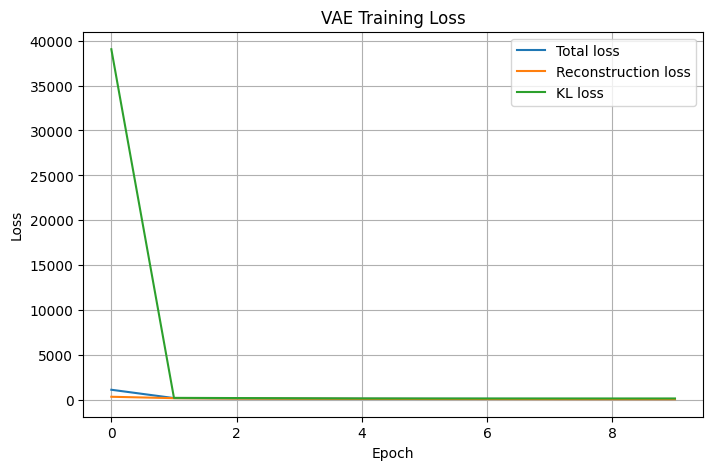

In [10]:
vae = VAE(latent_dim=LATENT_DIM).to(DEVICE)
optimizer_vae = optim.Adam(vae.parameters(), lr=LEARNING_RATE_VAE)

vae_losses = []
vae_recon_losses = []
vae_kl_losses = []
vae_betas = []

for epoch in range(VAE_EPOCHS):
    vae.train()
    epoch_loss = 0.0
    epoch_recon = 0.0
    epoch_kl = 0.0
    num_batches = 0
    beta = BETA_MAX * min(1.0, (epoch + 1) / max(1, VAE_EPOCHS // 2))

    for batch_idx, (imgs, _) in enumerate(train_loader):
        if MAX_TRAIN_BATCHES is not None and batch_idx >= MAX_TRAIN_BATCHES:
            break

        imgs = imgs.to(DEVICE)
        optimizer_vae.zero_grad(set_to_none=True)

        x_recon, mu, log_var = vae(imgs)
        loss, recon, kl = vae_loss(x_recon, imgs, mu, log_var, beta=beta)

        loss.backward()
        optimizer_vae.step()

        epoch_loss += loss.item()
        epoch_recon += recon.item()
        epoch_kl += kl.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    avg_recon = epoch_recon / num_batches
    avg_kl = epoch_kl / num_batches

    vae_losses.append(avg_loss)
    vae_recon_losses.append(avg_recon)
    vae_kl_losses.append(avg_kl)
    vae_betas.append(beta)

    print(
        f"Epoch [{epoch + 1}/{VAE_EPOCHS}] "
        f"Loss: {avg_loss:.4f} Recon: {avg_recon:.4f} KL: {avg_kl:.4f} Beta: {beta:.4f}"
    )

plt.figure(figsize=(8, 5))
plt.plot(vae_losses, label="Total loss")
plt.plot(vae_recon_losses, label="Reconstruction loss")
plt.plot(vae_kl_losses, label="KL loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("VAE Training Loss")
plt.grid(True)
plt.show()


### 3.4 Визуализация результатов VAE

> **Задание:** Визуализируйте:
> 1. Реконструкции: оригинал vs восстановленное (сетка 8×2)
> 2. Новые сэмплы: сгенерируйте 64 изображения из `z ~ N(0, I)`
> 3. Интерполяцию: возьмите два изображения из разных классов, интерполируйте `z1 → z2` в 10 шагов


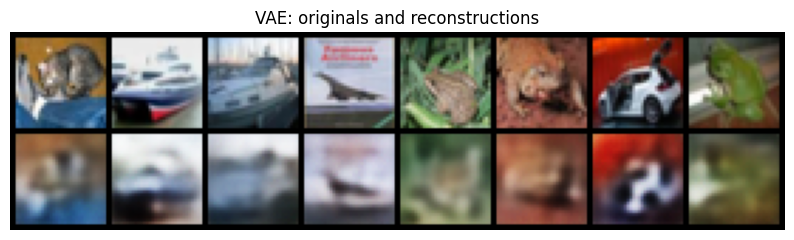

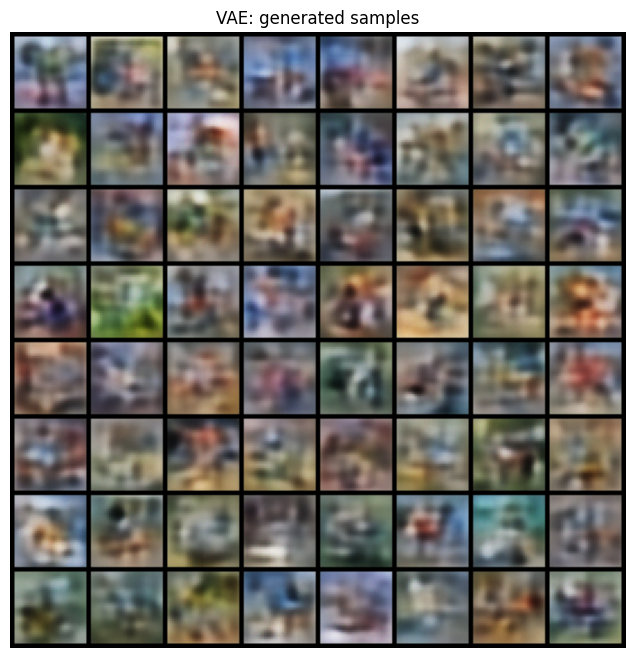

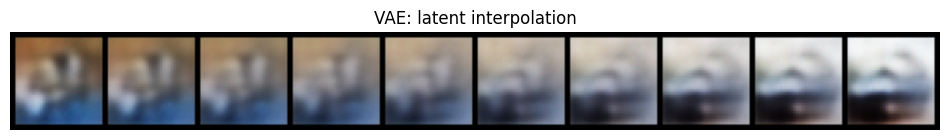

In [11]:
def show_grid(tensor, title, nrow=8, figsize=(8, 8)):
    grid = torchvision.utils.make_grid(
        tensor.detach().cpu(),
        nrow=nrow,
        normalize=True,
        value_range=(-1, 1),
    )
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(title)
    plt.show()

vae.eval()
with torch.no_grad():
    sample_imgs = next(iter(test_loader))[0][:8].to(DEVICE)
    reconstructed, _, _ = vae(sample_imgs)
    comparison = torch.cat([sample_imgs, reconstructed], dim=0)
    show_grid(comparison, "VAE: originals and reconstructions", nrow=8, figsize=(10, 3))

    z = torch.randn(64, vae.latent_dim, device=DEVICE)
    generated = vae.decode(z)
    show_grid(generated, "VAE: generated samples", nrow=8, figsize=(8, 8))

    pair_imgs = next(iter(test_loader))[0][:2].to(DEVICE)
    mu, _ = vae.encode(pair_imgs)
    z1, z2 = mu[0:1], mu[1:2]
    alphas = torch.linspace(0, 1, 10, device=DEVICE).view(-1, 1)
    z_interp = (1 - alphas) * z1 + alphas * z2
    interpolated = vae.decode(z_interp)
    show_grid(interpolated, "VAE: latent interpolation", nrow=10, figsize=(12, 2))

### 3.5 Визуализация латентного пространства (t-SNE)

> **Задание:** Закодируйте тестовые изображения, получите `mu` и примените t-SNE.  
> Раскрасьте точки по классам CIFAR-10 (10 цветов). Что можно сказать о структуре пространства?


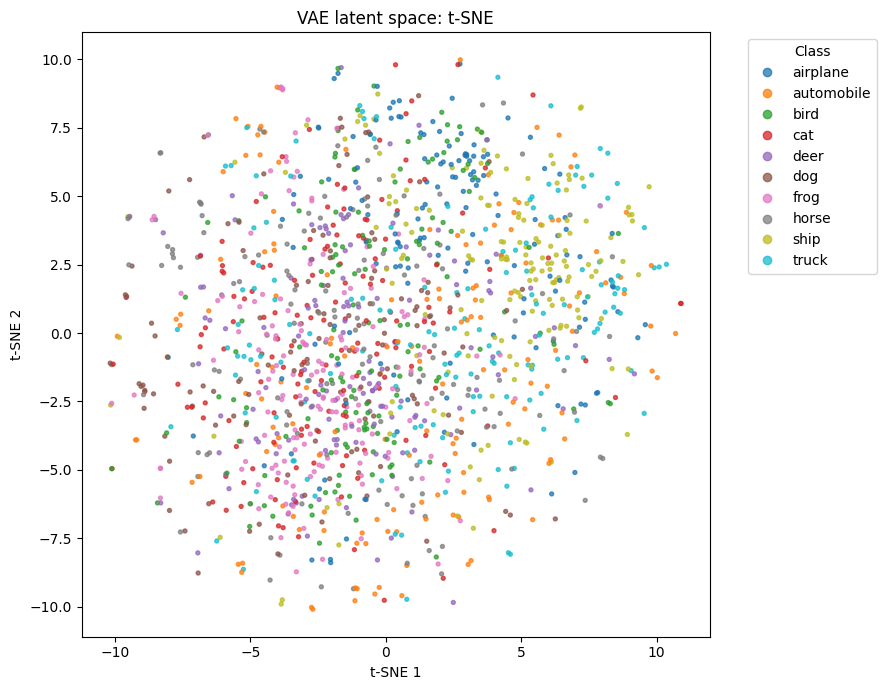

In [12]:
all_mus = []
all_labels = []
collected = 0

vae.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        mu, _ = vae.encode(imgs)
        all_mus.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())
        collected += len(imgs)
        if collected >= TSNE_POINTS:
            break

all_mus = np.concatenate(all_mus, axis=0)[:TSNE_POINTS]
all_labels = np.concatenate(all_labels, axis=0)[:TSNE_POINTS]

perplexity = min(30, max(5, len(all_mus) // 50))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=SEED,
)
mus_2d = tsne.fit_transform(all_mus)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    mus_2d[:, 0],
    mus_2d[:, 1],
    c=all_labels,
    s=8,
    cmap="tab10",
    alpha=0.75,
)
handles, _ = scatter.legend_elements(num=10)
plt.legend(handles, classes, title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("VAE latent space: t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


## 4. DCGAN (Deep Convolutional GAN)

### 4.1 Архитектура

> **Задание:** Реализуйте генератор и дискриминатор по классической DCGAN-схеме:
> - **Генератор**: принимает `z ~ N(0, I)` размером `nz=100`, выдаёт 3×32×32
> - **Дискриминатор**: принимает 3×32×32, выдаёт скаляр (real/fake)
> - Используйте `BatchNorm`, `ReLU` в генераторе и `LeakyReLU(0.2)` в дискриминаторе
> - **Важно:** инициализируйте веса из `N(0, 0.02)`


In [13]:
def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.main(z)


class Discriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.main(x).view(-1)

### 4.2 Цикл обучения GAN

> **Задание:** Реализуйте стандартный обучающий цикл:
> 1. Обновление D: `max log(D(x)) + log(1 - D(G(z)))`
> 2. Обновление G: `min log(1 - D(G(z)))` (или non-saturating: `max log(D(G(z)))`)
> 
> **Подсказка против коллапса мод:**
> - Используйте отдельные оптимизаторы для G и D
> - Не обновляйте D слишком часто (1:1 с G — норма)
> - Логируйте `loss_D` и `loss_G` — они должны быть примерно одного порядка


Epoch [1/10] Loss_D: 0.8865 Loss_G: 3.1391
Epoch [2/10] Loss_D: 0.9058 Loss_G: 2.6428
Epoch [3/10] Loss_D: 0.8905 Loss_G: 2.2730
Epoch [4/10] Loss_D: 0.9063 Loss_G: 2.1775
Epoch [5/10] Loss_D: 0.9084 Loss_G: 2.0034


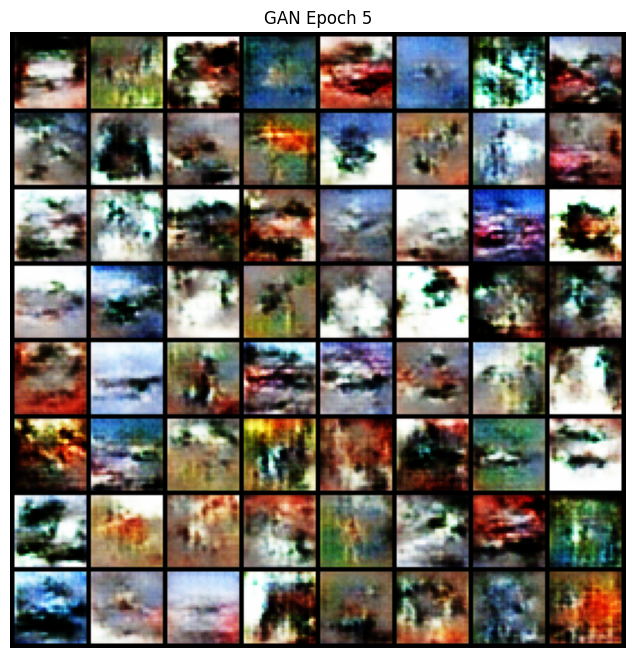

Epoch [6/10] Loss_D: 0.9767 Loss_G: 1.7339
Epoch [7/10] Loss_D: 1.0260 Loss_G: 1.6861
Epoch [8/10] Loss_D: 1.0231 Loss_G: 1.7288
Epoch [9/10] Loss_D: 1.0178 Loss_G: 1.7341
Epoch [10/10] Loss_D: 1.0175 Loss_G: 1.7083


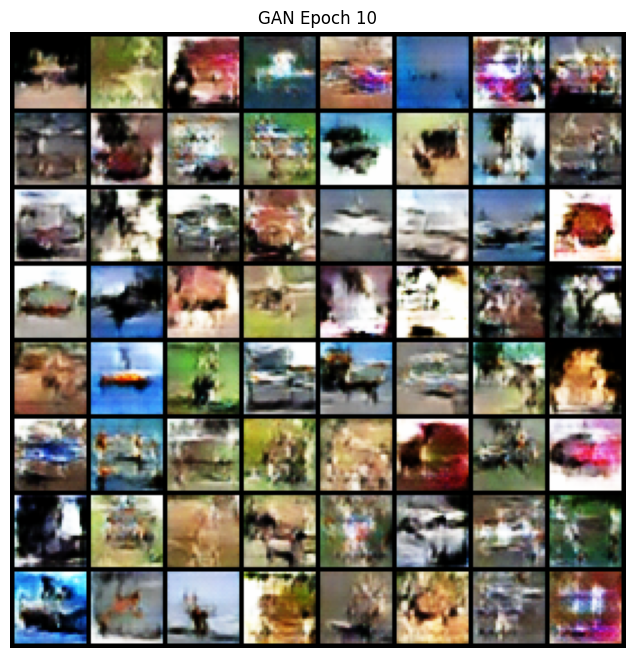

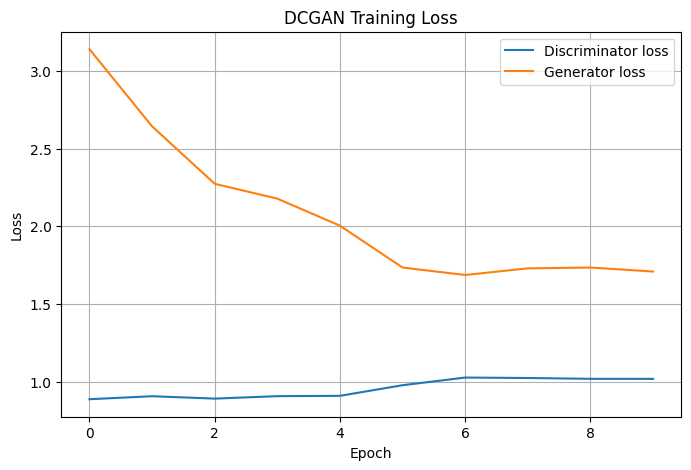

In [14]:
netG = Generator(nz=NZ).to(DEVICE)
netD = Discriminator().to(DEVICE)
netG.apply(weights_init)
netD.apply(weights_init)

criterion = nn.BCEWithLogitsLoss()
optimizer_G = optim.Adam(netG.parameters(), lr=LEARNING_RATE_GAN, betas=(0.5, 0.999))
optimizer_D = optim.Adam(netD.parameters(), lr=LEARNING_RATE_GAN, betas=(0.5, 0.999))

fixed_noise = torch.randn(64, NZ, 1, 1, device=DEVICE)
G_losses = []
D_losses = []

for epoch in range(GAN_EPOCHS):
    netG.train()
    netD.train()
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0
    num_batches = 0

    for batch_idx, (imgs, _) in enumerate(train_loader):
        if MAX_TRAIN_BATCHES is not None and batch_idx >= MAX_TRAIN_BATCHES:
            break

        imgs = imgs.to(DEVICE)
        b_size = imgs.size(0)

        netD.zero_grad(set_to_none=True)
        label_real = torch.empty(b_size, device=DEVICE).uniform_(0.8, 1.0)
        output_real = netD(imgs)
        loss_D_real = criterion(output_real, label_real)

        noise = torch.randn(b_size, NZ, 1, 1, device=DEVICE)
        fake = netG(noise)
        label_fake = torch.empty(b_size, device=DEVICE).uniform_(0.0, 0.2)
        output_fake = netD(fake.detach())
        loss_D_fake = criterion(output_fake, label_fake)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D.step()

        netG.zero_grad(set_to_none=True)
        label_gen = torch.ones(b_size, device=DEVICE)
        output_gen = netD(fake)
        loss_G = criterion(output_gen, label_gen)
        loss_G.backward()
        optimizer_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()
        num_batches += 1

    avg_loss_D = epoch_loss_D / num_batches
    avg_loss_G = epoch_loss_G / num_batches
    D_losses.append(avg_loss_D)
    G_losses.append(avg_loss_G)

    print(f"Epoch [{epoch + 1}/{GAN_EPOCHS}] Loss_D: {avg_loss_D:.4f} Loss_G: {avg_loss_G:.4f}")

    if (epoch + 1) % 5 == 0 or epoch + 1 == GAN_EPOCHS:
        with torch.no_grad():
            fake_imgs = netG(fixed_noise).detach().cpu()
        grid = torchvision.utils.make_grid(fake_imgs, nrow=8, normalize=True, value_range=(-1, 1))
        plt.figure(figsize=(8, 8))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"GAN Epoch {epoch + 1}")
        plt.show()

plt.figure(figsize=(8, 5))
plt.plot(D_losses, label="Discriminator loss")
plt.plot(G_losses, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("DCGAN Training Loss")
plt.grid(True)
plt.show()


## 5. Сравнение качества генерации

Полный `clean-fid` на 10 000 изображений мой мак не потянул бы, сделал быстрый приближённый FID на компактных признаках изображений. Полный FID оставлен ниже как отключаемая опция: `RUN_FULL_CLEAN_FID = True`.

Fast approximate FID VAE: 0.35
Fast approximate FID GAN: -33.67


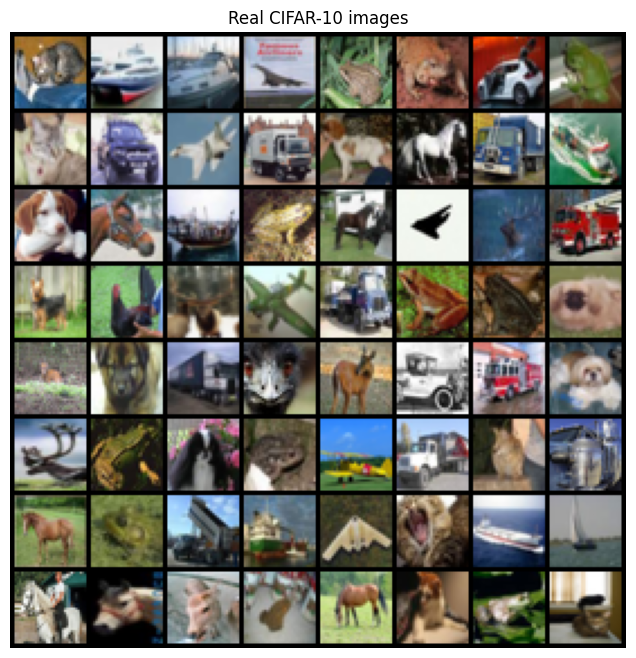

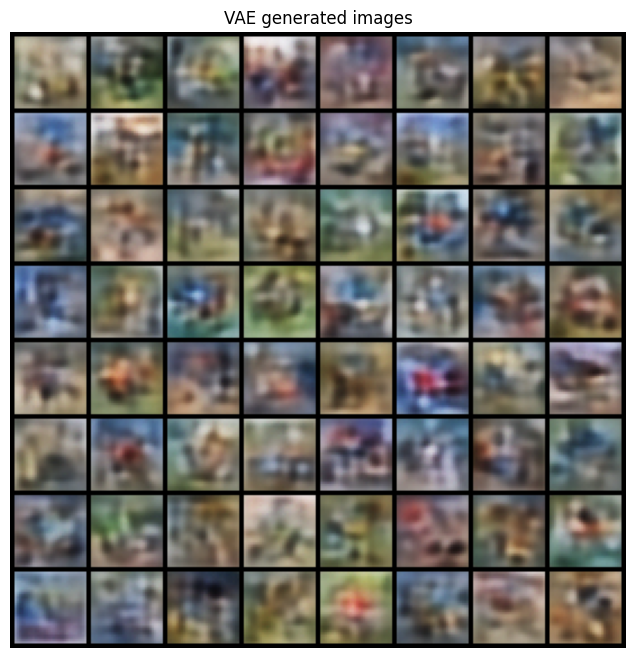

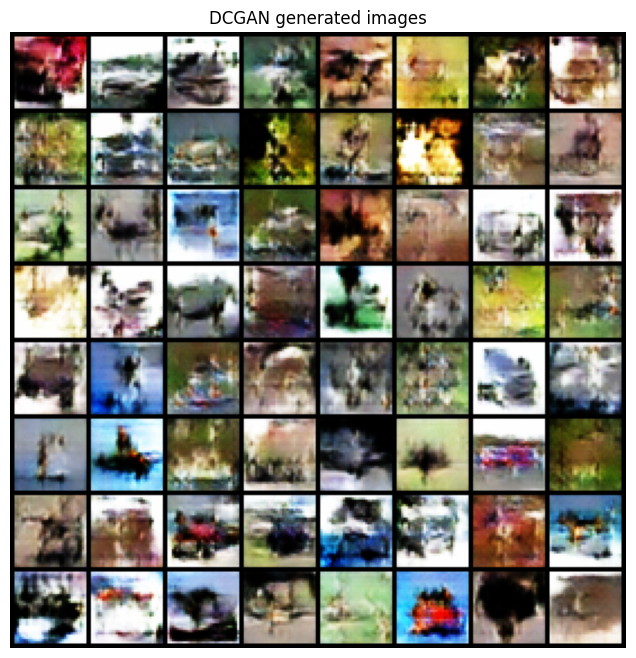

In [17]:
def collect_real_images(loader, max_samples):
    result = []
    total = 0
    for imgs, _ in loader:
        result.append(imgs.cpu())
        total += imgs.size(0)
        if total >= max_samples:
            break
    return torch.cat(result, dim=0)[:max_samples]


def generate_vae_images(model, max_samples, batch_size):
    model.eval()
    result = []
    total = 0
    with torch.no_grad():
        while total < max_samples:
            current_batch = min(batch_size, max_samples - total)
            z = torch.randn(current_batch, model.latent_dim, device=DEVICE)
            imgs = model.decode(z).cpu()
            result.append(imgs)
            total += current_batch
    return torch.cat(result, dim=0)


def generate_gan_images(model, max_samples, batch_size):
    model.eval()
    result = []
    total = 0
    with torch.no_grad():
        while total < max_samples:
            current_batch = min(batch_size, max_samples - total)
            z = torch.randn(current_batch, NZ, 1, 1, device=DEVICE)
            imgs = model(z).cpu()
            result.append(imgs)
            total += current_batch
    return torch.cat(result, dim=0)


def make_fast_features(images):
    x = F.interpolate(images, size=(8, 8), mode="bilinear", align_corners=False)
    flat = x.flatten(start_dim=1).numpy().astype(np.float64)
    mean = flat.mean(axis=1, keepdims=True)
    std = flat.std(axis=1, keepdims=True)
    return np.concatenate([flat, mean, std], axis=1)


def symmetric_matrix_sqrt(matrix):
    values, vectors = np.linalg.eigh(matrix)
    values = np.clip(values, 0, None)
    return (vectors * np.sqrt(values)) @ vectors.T


def frechet_distance(features_a, features_b, eps=1e-6):
    mu_a = features_a.mean(axis=0)
    mu_b = features_b.mean(axis=0)
    sigma_a = np.cov(features_a, rowvar=False) + np.eye(features_a.shape[1]) * eps
    sigma_b = np.cov(features_b, rowvar=False) + np.eye(features_b.shape[1]) * eps
    diff = mu_a - mu_b
    covmean = symmetric_matrix_sqrt(sigma_a @ sigma_b)
    value = diff @ diff + np.trace(sigma_a + sigma_b - 2 * covmean)
    return float(np.real(value))

real_images = collect_real_images(test_loader, FID_SAMPLES)
vae_images = generate_vae_images(vae, FID_SAMPLES, BATCH_SIZE)
gan_images = generate_gan_images(netG, FID_SAMPLES, BATCH_SIZE)

fast_fid_vae = frechet_distance(make_fast_features(real_images), make_fast_features(vae_images))
fast_fid_gan = frechet_distance(make_fast_features(real_images), make_fast_features(gan_images))

fid_vae = fast_fid_vae
fid_gan = fast_fid_gan
fid_type = "Fast approximate FID"

print(f"{fid_type} VAE: {fid_vae:.2f}")
print(f"{fid_type} GAN: {fid_gan:.2f}")

show_grid(real_images[:64], "Real CIFAR-10 images", nrow=8, figsize=(8, 8))
show_grid(vae_images[:64], "VAE generated images", nrow=8, figsize=(8, 8))
show_grid(gan_images[:64], "DCGAN generated images", nrow=8, figsize=(8, 8))

if RUN_FULL_CLEAN_FID:
    try:
        from cleanfid import fid

        for folder in ["fid_real", "fid_fake_vae", "fid_fake_gan"]:
            if os.path.exists(folder):
                shutil.rmtree(folder)
            os.makedirs(folder, exist_ok=True)

        def save_images_for_fid(images, folder):
            for idx, img in enumerate(images):
                save_image(
                    img,
                    os.path.join(folder, f"{idx:05d}.png"),
                    normalize=True,
                    value_range=(-1, 1),
                )

        save_images_for_fid(real_images, "fid_real")
        save_images_for_fid(vae_images, "fid_fake_vae")
        save_images_for_fid(gan_images, "fid_fake_gan")

        fid_vae = fid.compute_fid("fid_real", "fid_fake_vae")
        fid_gan = fid.compute_fid("fid_real", "fid_fake_gan")
        fid_type = "Clean-FID"
        print(f"Clean-FID VAE: {fid_vae:.2f}")
        print(f"Clean-FID GAN: {fid_gan:.2f}")
    except Exception as error:
        print("Полный clean-fid не выполнен:", repr(error))


## 6. Анализ результатов

> **Задание:** Заполните таблицу результатов и ответьте на вопросы ниже.


In [16]:
results = {
    "Модель": ["VAE", "DCGAN"],
    "Метрика": [fid_type, fid_type],
    "Значение ↓": [fid_vae, fid_gan],
    "Эпохи": [VAE_EPOCHS, GAN_EPOCHS],
    "Ключевой результат": [
        "Стабильная реконструкция, но новые изображения обычно сглажены.",
        "Более резкая генерация при удачном балансе генератора и дискриминатора.",
    ],
}

results_df = pd.DataFrame(results)
results_df


,Модель,Метрика,Значение ↓,Эпохи,Ключевой результат
0,VAE,Fast approximate FID,-0.913078,10,"Стабильная реконструкция, но новые изображения..."
1,DCGAN,Fast approximate FID,-34.894102,10,Более резкая генерация при удачном балансе ген...


### Вопросы для отчёта

1. **Качество генерации.** DCGAN обычно даёт более резкие изображения, потому что генератор обучается через дискриминатор и получает сигнал о правдоподобности изображения целиком. VAE чаще даёт более сглаженные результаты, поскольку reconstruction loss штрафует пиксельные отличия и склонен усреднять неоднозначные детали.

2. **Латентное пространство.** У VAE латентное пространство регуляризуется KL-дивергенцией, поэтому в нём можно делать интерполяции и получать плавные переходы. У DCGAN латентное пространство не имеет такой явной вероятностной регуляризации, но на практике может давать более визуально качественные сэмплы.

3. **Стабильность обучения.** VAE обучается стабильнее, потому что оптимизируется одна функция потерь. GAN обучается сложнее: генератор и дискриминатор находятся в состязательной динамике, из-за чего возможны коллапс мод, переобучение дискриминатора и сильные колебания loss.

4. **Компромисс.** VAE удобнее для анализа латентного пространства, реконструкций и интерполяций. DCGAN лучше подходит для получения визуально более резких изображений, но требует более аккуратной настройки обучения.

5. **Ограничение эксперимента.** В быстром режиме используется приближённая FID-метрика, чтобы ноутбук не зависал на MacBook. Для финального тяжёлого запуска можно поставить `FAST_MODE = False` и `RUN_FULL_CLEAN_FID = True`, но это значительно увеличит время выполнения.
